<a href="https://colab.research.google.com/github/langnguyengiahan-stack/Analyse-Global-Electric-Vehicle-Ecosystem/blob/main/Analyse_Global_Electric_Vehicle_Ecosystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import statistics
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
stations_data = pd.read_csv('Charging_Stations.csv')
consumer_data = pd.read_csv('Consumer_Reviews.csv')
countries_data = pd.read_csv('countries.csv')
manufacturers_data = pd.read_csv('manufacturers.csv')
models_data = pd.read_csv('vehicle_models.csv')
vehicles_data = pd.read_csv('EV_Vehicles.csv')

In [3]:
datasets = {"countries": countries_data,
            "consumer":consumer_data,
            "stations": stations_data,
            "manufacturers": manufacturers_data,
            "models": models_data,
            "vehicles": vehicles_data}
summary = []

In [4]:
summary = []
for name,df in datasets.items():
  summary.append(
        [
            name,
            df.shape[0],
            df.shape[1],
            df.duplicated().sum(),
            df.isna().sum().sum(),
        ]
    )

summary=pd.DataFrame(
summary,
columns=[
"Dataset",
"Rows",
"Columns",
"Duplicate Rows",
"Missing Values"
])
summary

,Dataset,Rows,Columns,Duplicate Rows,Missing Values
0,countries,15,12,0,0
1,consumer,5000,20,0,0
2,stations,1000,16,0,0
3,manufacturers,25,5,0,0
4,models,30,9,0,0
5,vehicles,5000,20,0,0


In [5]:
summary.style.background_gradient(
    cmap="Blues", subset=["Rows", "Columns"])

,Dataset,Rows,Columns,Duplicate Rows,Missing Values
0,countries,15,12,0,0
1,consumer,5000,20,0,0
2,stations,1000,16,0,0
3,manufacturers,25,5,0,0
4,models,30,9,0,0
5,vehicles,5000,20,0,0


In [6]:
shape=[]

for name,df in datasets.items():

    shape.append([
        name,
        df.shape[0],
        df.shape[1]
    ])

shape=pd.DataFrame(
shape,
columns=[
"Dataset",
"Rows",
"Columns"
])

shape


,Dataset,Rows,Columns
0,countries,15,12
1,consumer,5000,20
2,stations,1000,16
3,manufacturers,25,5
4,models,30,9
5,vehicles,5000,20


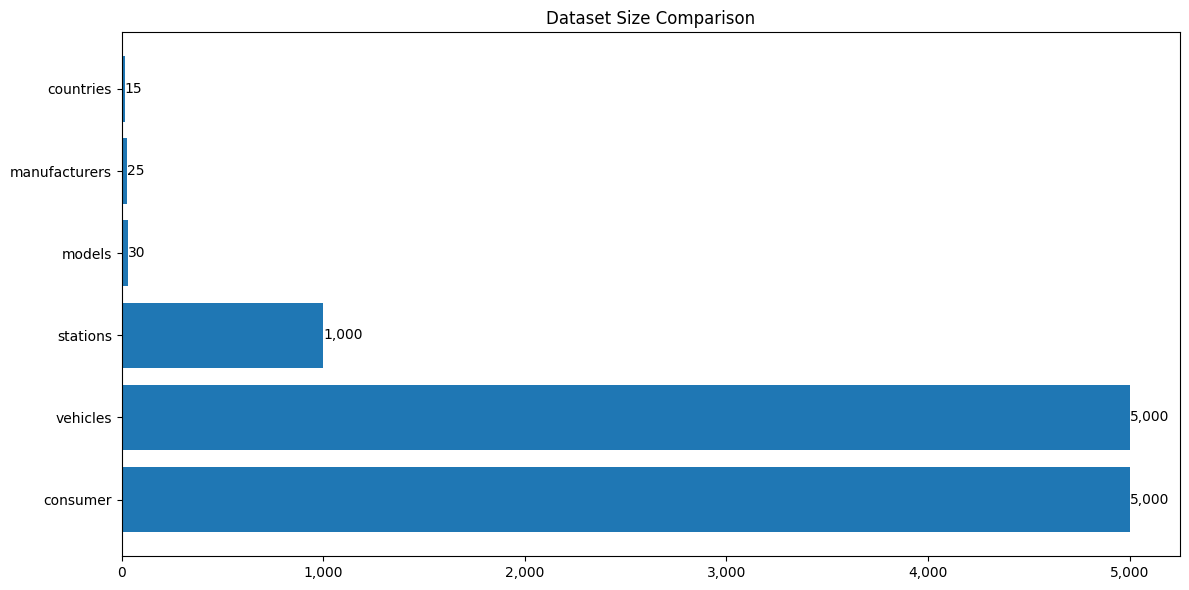

In [7]:
shape=shape.sort_values(
"Rows",
ascending=False
)

fig,ax=plt.subplots(figsize=(12,6))

bars=ax.barh(
shape["Dataset"],
shape["Rows"]
)

ax.set_title("Dataset Size Comparison")

ax.xaxis.set_major_formatter(
ticker.StrMethodFormatter('{x:,.0f}')
)
for b in bars:
    ax.text(
        b.get_width(),
        b.get_y()+b.get_height()/2,
        f"{int(b.get_width()):,}",
        va="center"
    )

plt.tight_layout()
plt.show()

**bold text:** EV Adoption Countries Ranking

In [8]:
import plotly.express as px
countries_data["EV_Adoption_%"] = pd.to_numeric(countries_data["EV_Adoption_%"], errors="coerce")

top = countries_data.dropna(subset=["EV_Adoption_%"]).sort_values(
    "EV_Adoption_%", ascending=False
).head(15)

fig = px.bar(
    top,
    x="EV_Adoption_%",
    y="Country",
    orientation="h",
    title="Comparing EV Adoption Rates Across Countries",
    color="EV_Adoption_%",
    text="EV_Adoption_%",
    color_continuous_scale="Viridis"
)

fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")

fig.update_layout(
    template="plotly_white",
    yaxis={"categoryorder": "total ascending"},
    xaxis_title="EV Adoption (%)",
    yaxis_title="",
    height=650
)

fig.show()

GDP vs EV Adoptions

In [9]:
fig=px.scatter(
    countries_data,
    x="GDP_Per_Capita_USD",
    y="EV_Adoption_%",
    color="Continent",
    size="Population_M",
    hover_name="Country",
    title="GDP per Capita vs EV Adoption"
)

fig.update_layout(template="plotly_white")

fig.show()

Renewable Energy

In [10]:
fig=px.scatter(
    countries_data,
    x="Renewable_Energy_%",
    y="EV_Adoption_%",
    color="Continent",
    size="Population_M",
    hover_name="Country",
    title="Renewable Energy vs EV Adoption"
)

fig.update_layout(template="plotly_white")

fig.show()


Electricity vs Petrol Prices

In [11]:
fig=px.scatter(
    countries_data,
    x="Electricity_Price_USD_kWh",
    y="Petrol_Price_USD_L",
    color="EV_Adoption_%",
    hover_name="Country",
    size="Population_M",
    title="Electricity Price vs Petrol Price"
)

fig.update_layout(template="plotly_white")

fig.show()

Number of Manufacturers by Country

In [12]:
import plotly.express as px

country_count=(
    manufacturers_data.groupby("Country")
    .size()
    .reset_index(name="Manufacturers")
    .sort_values("Manufacturers",ascending=False)
)

fig=px.bar(
    country_count,
    x="Country",
    y="Manufacturers",
    color="Manufacturers",
    text="Manufacturers",
    title="Number of EV Manufacturers by Country"
)

fig.show()


Battery Performance Analysis

Charging Station in Countries

In [13]:
country_station=(
    stations_data.groupby("Country")
    .size()
    .reset_index(name="Stations")
    .sort_values("Stations",ascending=False)
)

fig=px.bar(
    country_station.head(20),
    x="Country",
    y="Stations",
    color="Stations",
    text="Stations"
)

fig.update_layout(title="Top Countries by Charging Stations")

fig.show()

In [14]:
network=(
    stations_data.groupby("Network")
    .size()
    .reset_index(name="Stations")
)

fig=px.pie(
    network,
    names="Network",
    values="Stations",
    hole=.45
)

fig.update_layout(title="Charging Network Distribution")

fig.show()

In [15]:
charger=(
    stations_data.groupby("Charger_Type")
    .size()
    .reset_index(name="Count")
)

fig=px.bar(
    charger,
    x="Charger_Type",
    y="Count",
    color="Count",
    text="Count"
)

fig.update_layout(title="Charger Type Distribution")

fig.show()

In [16]:
connector=(
    stations_data.groupby("Connector")
    .size()
    .reset_index(name="Stations")
)

fig=px.bar(
    connector,
    x="Connector",
    y="Stations",
    color="Stations",
    text="Stations"
)

fig.update_layout(title="Connector Distribution")

fig.show()

In [17]:
annual_growth = (
    stations_data.groupby(["Country", "Installation_Year"])
    .size()
    .reset_index(name="New_Installations")
)


annual_growth = annual_growth.sort_values(
    by=["Country", "Installation_Year"]
).reset_index(drop=True)

annual_growth["Total_Stations"] = annual_growth.groupby("Country")[
    "New_Installations"
].cumsum()

annual_growth["YoY_Growth_%"] = (
    annual_growth.groupby("Country")["Total_Stations"].pct_change() * 100
).round(2)

annual_growth.head()

,Country,Installation_Year,New_Installations,Total_Stations,YoY_Growth_%
0,Canada,2015,4,4,NaN
1,Canada,2016,13,17,325.00
2,Canada,2017,3,20,17.65
3,Canada,2018,8,28,40.00
4,Canada,2019,8,36,28.57


In [18]:
import plotly.express as px

fig_new = px.bar(
    annual_growth,
    x="Installation_Year",
    y="New_Installations",
    color="Country",
    barmode="group",
    title="Annual New Charging Station Installations by Country",
    labels={
        "Installation Year": "Year",
        "New_Installations": "New Stations Installed",
    },
)

fig_new.update_layout(height=500)
fig_new.show()

In [19]:
fig_total = px.line(
    annual_growth,
    x="Installation_Year",
    y="Total_Stations",
    color="Country",
    title="Cumulative Total EV Charging Stations over Time",
    labels={
        "Installation Year": "Year",
        "Total_Stations": "Total Active Stations",
    },
    markers=True,
)

fig_total.update_layout(height=500)
fig_total.show()

Brand Distribution

In [20]:
fig=px.pie(
manufacturers_data,
names="Country",
title="Manufacturer Distribution by Country",
hole=.45
)

fig.update_layout(title_x=0.5)

fig.show()

In [21]:
brand_summary=(
vehicles_data.groupby("Brand")
.agg(
Vehicles=("Vehicle_ID","count"),
Avg_Range=("Range_km","mean"),
Avg_Price=("Price_USD","mean"),
Avg_HP=("Horsepower","mean")
)
.reset_index()
)

brand_summary.head()

,Brand,Vehicles,Avg_Range,Avg_Price,Avg_HP
0,BMW,498,532.738956,72896.020080,335.851406
1,BYD,1037,448.270974,65242.998071,344.363549
2,Hyundai,495,481.967677,68466.662626,342.955556
3,Kia,484,474.012397,67594.698347,342.551653
4,Mahindra,503,488.200795,68984.590457,340.393638


In [22]:
fig=px.scatter(
vehicles_data,
x="Price_USD",
y="Range_km",
color="Brand",
opacity=.65
)

fig.update_layout(title="Price vs Driving Range")

fig.show()

In [23]:
brand_value=(
vehicles_data.groupby("Brand")
.agg(
Avg_Range=("Range_km","mean"),
Avg_Price=("Price_USD","mean"),
Vehicles=("Vehicle_ID","count")
)
.reset_index()
)

brand_value["Value_Index"]=(
brand_value["Avg_Range"]/
brand_value["Avg_Price"]*1000
)

brand_value=brand_value.sort_values(
"Value_Index",
ascending=False
)

fig=px.bar(
brand_value.head(15),
x="Brand",y="Value_Index",
color="Avg_Range",
text="Value_Index"
)

fig.update_layout(title="Top Value-for-Money EV Brands")

fig.show()